# GitHub Engineering Intelligence Platform

## Notebook 01 — Dataset Exploration & Profiling Report

---

### Dataset Information

| Attribute | Details |
|-----------|---------|
| **Dataset** | GH Archive |
| **Coverage** | 7 consecutive days of public GitHub events |
| **Time Period** | 01 Jan 2026 – 07 Jan 2026 |
| **Data Source** | https://www.gharchive.org |
| **Files Processed** | 168 hourly JSON files |
| **Dataset Size** | ~34 GB |
| **Records Processed** | 24,698,553 GitHub events |
| **Author** | Harshita Shibe |
| **Date** | July 12, 2026 |



### Objective

This notebook performs a comprehensive profiling pass over the raw GitHub Archive dataset prior to ETL implementation and warehouse design.

The primary objective is to understand the dataset's structure, validate data quality, identify potential anomalies, and generate profiling artifacts that guide the design of a scalable analytical data warehouse.

Every statistic presented in this notebook—including validation metrics, event distributions, schema discovery, activity analysis, and contributor rankings—is generated from a **single-pass scan** over the complete dataset, following production-grade data profiling practices.



### Notebook Workflow

| Step | Description |
|:---|:---|
| **1. Project Setup** | Environment configuration and project initialization |
| **2. Dataset Inventory** | Verification of folder hierarchy and file organization |
| **3. Single-Pass Dataset Scan** | Validation and profiling of all GitHub events |
| **4. Dataset Statistics** | Overall quality metrics and summary statistics |
| **5. Data Dictionary** | Schema discovery and field documentation |
| **6. Event Distribution** | Frequency analysis of GitHub event types |
| **7. Daily Activity** | Event volume across the seven-day window |
| **8. Hourly Activity** | Temporal activity patterns by hour |
| **9. Repository Visibility** | Public versus private event analysis |
| **10. Missing Value Analysis** | Completeness assessment of key attributes |
| **11. Duplicate Detection** | Validation of event uniqueness |
| **12. Contributor Analysis** | Most active users, repositories, and organizations |
| **13. Activity Distributions** | Distributional analysis and visualization |
| **14. Schema Discovery** | Payload inspection and event-specific schemas |
| **15. Report Generation** | Export of profiling artifacts (CSV & figures) |
| **16. Key Findings** | Summary observations and transition to ETL |


> **Notebook Output**

This notebook produces reusable profiling reports under the `reports/` directory and establishes the foundation for **Notebook 02 – ETL Pipeline**, where the raw JSON events are transformed into warehouse-ready dimension and fact tables.

### Project Setup

Mounts the data source and defines all paths and constants used throughout
the notebook. No hardcoded paths appear elsewhere.

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import re
import json
import glob
import time
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/GitHub_Engineering_Intelligence/data/raw"
REPORTS_PATH = "/content/drive/MyDrive/GitHub_Engineering_Intelligence/reports"

os.makedirs(REPORTS_PATH, exist_ok=True)

### Dataset Inventory

Before processing begins, the raw dataset layout is confirmed: one folder per
day, with 24 hourly files per folder, matching the expected GH Archive
structure.

In [30]:
files = sorted(glob.glob(f"{DATA_PATH}/*/*.json"))

day_file_counts = Counter(os.path.basename(os.path.dirname(f)) for f in files)

for day in sorted(day_file_counts):
    print(f"{day} -> {day_file_counts[day]} files")

print("\nTotal Days :", len(day_file_counts))
print("Total Files:", len(files))


2026-01-01 -> 24 files
2026-01-02 -> 24 files
2026-01-03 -> 24 files
2026-01-04 -> 24 files
2026-01-05 -> 24 files
2026-01-06 -> 24 files
2026-01-07 -> 24 files

Total Days : 7
Total Files: 168


#### Folder Structure
The raw dataset follows a date-partitioned folder structure,
where each directory represents one day of GitHub activity
and contains 24 hourly JSON files.

In [32]:
def print_folder_tree(data_path: str, day_counts: dict) -> None:
    print(os.path.basename(data_path.rstrip("/")) + "/")
    print("└── raw/")

    days = sorted(day_counts)
    for i, day in enumerate(days):
        connector = "└──" if i == len(days) - 1 else "├──"
        prefix = "    " if i == len(days) - 1 else "│   "
        print(f"    {connector} {day}/")
        print(f"    {prefix}      {day_counts[day]} JSON files")


print_folder_tree(DATA_PATH, day_file_counts)


raw/
└── raw/
    ├── 2026-01-01/
    │         24 JSON files
    ├── 2026-01-02/
    │         24 JSON files
    ├── 2026-01-03/
    │         24 JSON files
    ├── 2026-01-04/
    │         24 JSON files
    ├── 2026-01-05/
    │         24 JSON files
    ├── 2026-01-06/
    │         24 JSON files
    └── 2026-01-07/
              24 JSON files


#### Dataset Size on Disk

In [33]:
total_size_bytes = sum(os.path.getsize(f) for f in files)
total_size_gb = round(total_size_bytes / (1024 ** 3), 2)

print(f"Dataset Size: {total_size_gb} GB")


Dataset Size: 31.88 GB


### Single-Pass Dataset Scan

The full dataset is read **once**. This single loop over all 168 files
populates every counter and metric used in the remainder of this report —
validation results, event-type and daily/hourly distributions, actor/repo/org
frequency, missing-value flags, duplicate-ID tracking, and one representative
sample payload per event type.

This design avoids re-reading the dataset for each metric, which would
otherwise require four to five separate full scans.

In [34]:
# Record-level counters
good_records = 0
bad_records = 0
error_log = []

# Distribution counters
event_counter = Counter()
daily_counter = Counter()
hourly_counter = Counter()
actor_counter = Counter()
repo_counter = Counter()
org_counter = Counter()
public_counter = Counter()

# Data quality
seen_event_ids = set()
duplicate_event_ids = set()

missing_actor = 0
missing_repo = 0
missing_org = 0
missing_created_at = 0
missing_event_id = 0

# Schema discovery
sample_payloads = {}

HOUR_PATTERN = re.compile(r"-(\d+)\.json$")

start_time = time.time()

for file in files:
    day = os.path.basename(os.path.dirname(file))
    hour_match = HOUR_PATTERN.search(os.path.basename(file))
    hour = int(hour_match.group(1)) if hour_match else None

    with open(file, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):

            # Validation
            try:
                event = json.loads(line)
            except json.JSONDecodeError as e:
                bad_records += 1
                error_log.append({
                    "file": file,
                    "line_number": line_no,
                    "error_type": type(e).__name__,
                    "error_message": str(e),
                    "raw_record": line[:300],
                })
                continue

            good_records += 1

            # Event type, daily & hourly activity
            event_type = event.get("type")
            event_counter[event_type] += 1
            daily_counter[day] += 1
            if hour is not None:
                hourly_counter[hour] += 1

            # Public vs private
            public_counter[event.get("public")] += 1

            # Event ID / duplicate check
            event_id = event.get("id")
            if event_id is None:
                missing_event_id += 1
            elif event_id in seen_event_ids:
                duplicate_event_ids.add(event_id)
            else:
                seen_event_ids.add(event_id)

            # Actor
            actor = event.get("actor") or {}
            if not actor.get("login"):
                missing_actor += 1
            else:
                actor_counter[actor["login"]] += 1

            # Repo
            repo = event.get("repo") or {}
            if not repo.get("name"):
                missing_repo += 1
            else:
                repo_counter[repo["name"]] += 1

            # Org (informational — not a quality failure)
            org = event.get("org") or {}
            if not org.get("login"):
                missing_org += 1
            else:
                org_counter[org["login"]] += 1

            # created_at
            if not event.get("created_at"):
                missing_created_at += 1

            # Sample payload capture (one per event type)
            if event_type not in sample_payloads:
                sample_payloads[event_type] = event.get("payload")

elapsed = round(time.time() - start_time, 1)
print(f"Single-pass scan complete in {elapsed}s")
print(f"Good records: {good_records:,} | Bad records: {bad_records:,}")


Single-pass scan complete in 743.4s
Good records: 24,698,553 | Bad records: 0


### Dataset Statistics Dashboard

A single executive-summary table covering dataset scale, data quality, and
entity cardinality — the first thing a reader should see before drilling into
detail.

In [35]:
total_records = good_records + bad_records
success_rate = (good_records / total_records) * 100

dashboard_rows = [
    ("Days", len(day_file_counts)),
    ("JSON Files", len(files)),
    ("Dataset Size (GB)", total_size_gb),
    ("Total Events", f"{total_records:,}"),
    ("Good Records", f"{good_records:,}"),
    ("Bad Records", f"{bad_records:,}"),
    ("Success Rate", f"{success_rate:.4f}%"),
    ("Unique Event Types", len(event_counter)),
    ("Unique Users", f"{len(actor_counter):,}"),
    ("Unique Repositories", f"{len(repo_counter):,}"),
    ("Unique Organizations", f"{len(org_counter):,}"),
    ("Duplicate Event IDs", len(duplicate_event_ids)),
]

print("=" * 45)
print(f"{'Metric':<28}{'Value':>17}")
print("-" * 45)
for metric, value in dashboard_rows:
    print(f"{metric:<28}{str(value):>17}")
print("=" * 45)

profile_df = pd.DataFrame(dashboard_rows, columns=["Metric", "Value"])


Metric                                  Value
---------------------------------------------
Days                                        7
JSON Files                                168
Dataset Size (GB)                       31.88
Total Events                       24,698,553
Good Records                       24,698,553
Bad Records                                 0
Success Rate                        100.0000%
Unique Event Types                         16
Unique Users                        2,106,219
Unique Repositories                 3,037,027
Unique Organizations                  135,125
Duplicate Event IDs                        68


### Data Dictionary

In [36]:
data_dictionary = pd.DataFrame([
    {"Field": "id",         "Type": "String",    "Nullable": "No",  "Description": "Unique event identifier"},
    {"Field": "type",       "Type": "String",    "Nullable": "No",  "Description": "GitHub event type (e.g. PushEvent, PullRequestEvent)"},
    {"Field": "actor",      "Type": "Object",    "Nullable": "No",  "Description": "User performing the action"},
    {"Field": "repo",       "Type": "Object",    "Nullable": "No",  "Description": "Repository involved in the event"},
    {"Field": "payload",    "Type": "Object",    "Nullable": "No",  "Description": "Event-specific metadata (structure varies by event type)"},
    {"Field": "created_at", "Type": "Timestamp", "Nullable": "No",  "Description": "Event creation time (UTC)"},
    {"Field": "public",     "Type": "Boolean",   "Nullable": "No",  "Description": "Public visibility flag"},
    {"Field": "org",        "Type": "Object",    "Nullable": "Yes", "Description": "Organization, present only if the repo belongs to one"},
])

data_dictionary


,Field,Type,Nullable,Description
0,id,String,No,Unique event identifier
1,type,String,No,"GitHub event type (e.g. PushEvent, PullRequest..."
2,actor,Object,No,User performing the action
3,repo,Object,No,Repository involved in the event
4,payload,Object,No,Event-specific metadata (structure varies by e...
5,created_at,Timestamp,No,Event creation time (UTC)
6,public,Boolean,No,Public visibility flag
7,org,Object,Yes,"Organization, present only if the repo belongs..."


### Event Type Distribution

In [37]:
event_df = (
    pd.DataFrame(event_counter.items(), columns=["event_type", "record_count"])
    .sort_values("record_count", ascending=False)
    .reset_index(drop=True)
)
event_df["pct_of_total"] = (event_df["record_count"] / event_df["record_count"].sum() * 100).round(2)

event_df


,event_type,record_count,pct_of_total
0,PushEvent,17194943,69.62
1,PullRequestEvent,2029170,8.22
2,CreateEvent,1680474,6.80
3,IssueCommentEvent,758262,3.07
4,WatchEvent,678949,2.75
5,DeleteEvent,642759,2.60
6,IssuesEvent,569711,2.31
7,PullRequestReviewCommentEvent,399512,1.62
8,PullRequestReviewEvent,390746,1.58
9,ForkEvent,136151,0.55


### Event Type Distribution — Visualized

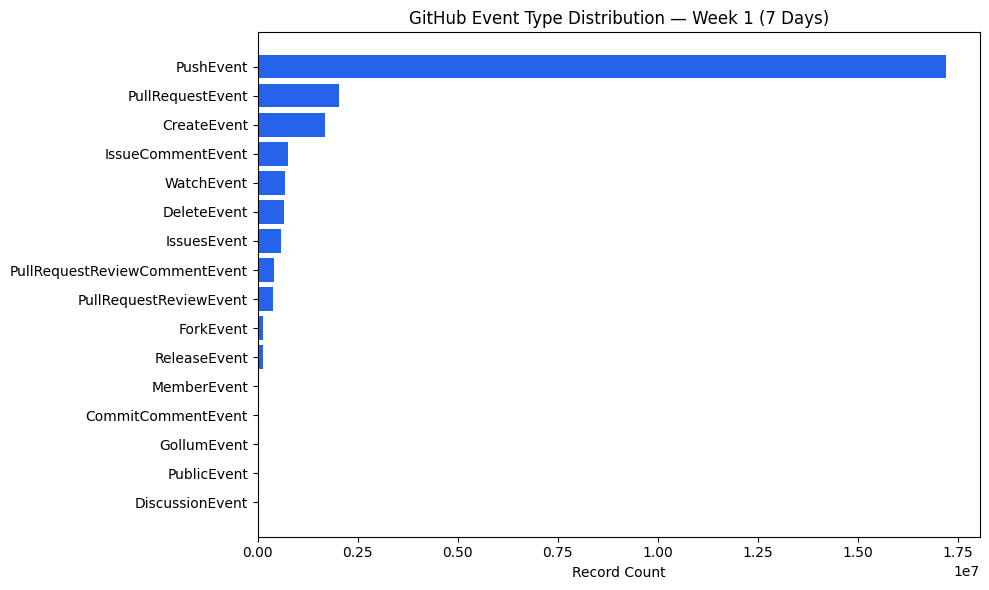

In [38]:
plt.figure(figsize=(10, 6))
plt.barh(event_df["event_type"], event_df["record_count"], color="#2563eb")
plt.gca().invert_yaxis()
plt.xlabel("Record Count")
plt.title("GitHub Event Type Distribution — Week 1 (7 Days)")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "event_type_distribution.png"), dpi=150)
plt.show()


### Daily Activity

In [39]:
daily_df = (
    pd.DataFrame(daily_counter.items(), columns=["day", "record_count"])
    .sort_values("day")
    .reset_index(drop=True)
)

daily_df


,day,record_count
0,2026-01-01,3504602
1,2026-01-02,3511655
2,2026-01-03,3510021
3,2026-01-04,3519310
4,2026-01-05,3563604
5,2026-01-06,3555506
6,2026-01-07,3533855


### Daily Activity — Visualized

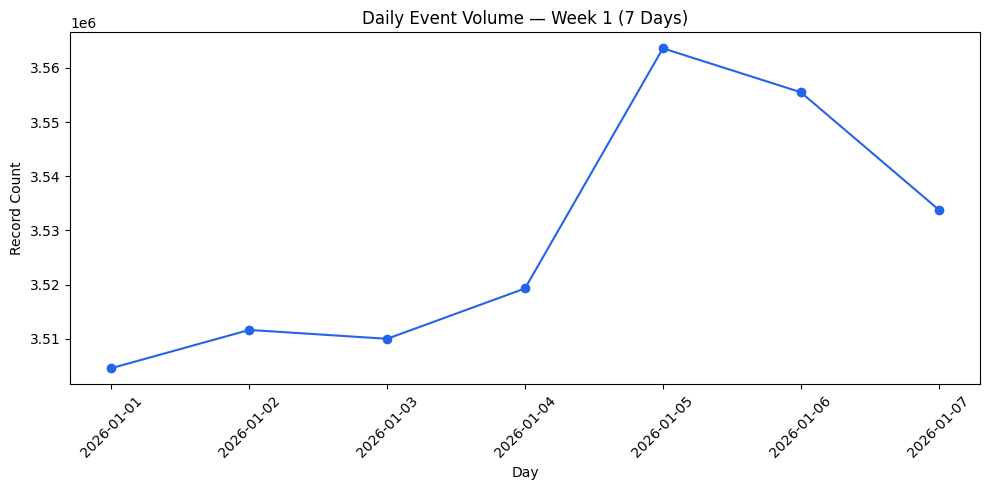

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(daily_df["day"], daily_df["record_count"], marker="o", color="#2563eb")
plt.xlabel("Day")
plt.ylabel("Record Count")
plt.title("Daily Event Volume — Week 1 (7 Days)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "daily_activity.png"), dpi=150)
plt.show()


### Hour-Wise Activity

Each raw file corresponds to a single UTC hour (`0.json`–`23.json`).
Aggregating across all 7 days reveals the platform's activity cycle
independent of any single day's variance.

In [41]:
hourly_df = (
    pd.DataFrame(hourly_counter.items(), columns=["hour_utc", "record_count"])
    .sort_values("hour_utc")
    .reset_index(drop=True)
)

hourly_df


,hour_utc,record_count
0,0,992585
1,1,1043592
2,2,1007134
3,3,981096
4,4,993091
5,5,999743
6,6,1012786
7,7,1010717
8,8,1016608
9,9,1036600


### Hour-Wise Activity — Visualized

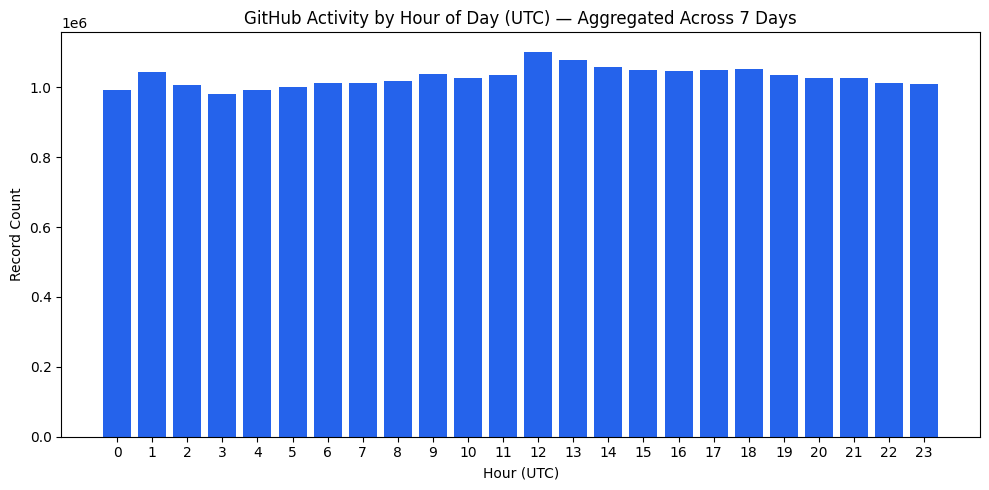

In [42]:
plt.figure(figsize=(10, 5))
plt.bar(hourly_df["hour_utc"], hourly_df["record_count"], color="#2563eb")
plt.xlabel("Hour (UTC)")
plt.ylabel("Record Count")
plt.title("GitHub Activity by Hour of Day (UTC) — Aggregated Across 7 Days")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "hourly_activity.png"), dpi=150)
plt.show()


### Public vs Private Events

GH Archive records only publicly visible GitHub activity; this section
confirms that expectation against the actual `public` field distribution.

    public  record_count
0   Public      24697891
1  Private           662


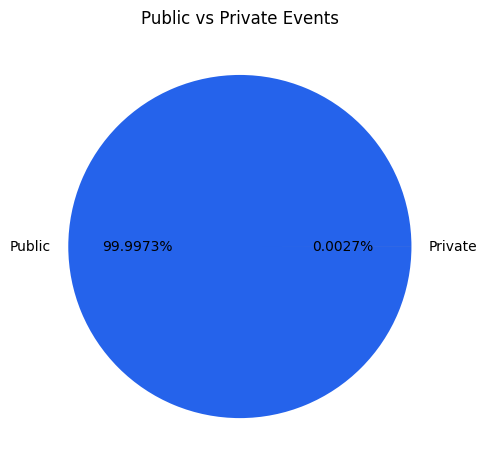

In [43]:
public_df = pd.DataFrame(public_counter.items(), columns=["public", "record_count"])
public_df["public"] = public_df["public"].map({True: "Public", False: "Private", None: "Unknown"})

print(public_df)

plt.figure(figsize=(5, 5))
plt.pie(public_df["record_count"], labels=public_df["public"], autopct="%1.4f%%", colors=["#2563eb", "#f97316"])
plt.title("Public vs Private Events")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "public_vs_private.png"), dpi=150)
plt.show()


### Missing Value Analysis

Field-level completeness for `actor`, `repo`, `created_at`, and `event_id`.

`org` is reported separately and is **not treated as a data-quality defect** —
a large share of GitHub activity originates from individually owned
repositories, which legitimately have no associated organization.

In [44]:
missing_df = pd.DataFrame([
    {"field": "actor",       "missing_count": missing_actor,       "missing_pct": round(missing_actor / good_records * 100, 4)},
    {"field": "repo",        "missing_count": missing_repo,        "missing_pct": round(missing_repo / good_records * 100, 4)},
    {"field": "created_at",  "missing_count": missing_created_at,  "missing_pct": round(missing_created_at / good_records * 100, 4)},
    {"field": "event_id",    "missing_count": missing_event_id,    "missing_pct": round(missing_event_id / good_records * 100, 4)},
    {"field": "org (expected — not all events have one)", "missing_count": missing_org, "missing_pct": round(missing_org / good_records * 100, 4)},
])

missing_df


,field,missing_count,missing_pct
0,actor,0,0.0000
1,repo,825,0.0033
2,created_at,0,0.0000
3,event_id,0,0.0000
4,org (expected — not all events have one),20054395,81.1966


### Duplicate Event ID Check

GitHub event IDs are expected to be globally unique. This check confirms
whether any records were captured more than once — for example, due to
overlapping hourly file boundaries or a download/copy issue.

In [45]:
print("Duplicate Event IDs :", len(duplicate_event_ids))

if duplicate_event_ids:
    sample_dupes = list(duplicate_event_ids)[:10]
    print("Sample duplicate IDs:", sample_dupes)


Duplicate Event IDs : 68
Sample duplicate IDs: ['7125098679', '7202625851', '7202603745', '7202621316', '7202603978', '7202625850', '7202621229', '7202599435', '7113963945', '7202599376']


###Top Contributors

The most active users, repositories, and organizations by event volume
across the 7-day window.

In [46]:
top_users = pd.DataFrame(actor_counter.most_common(20), columns=["user", "event_count"])
top_repos = pd.DataFrame(repo_counter.most_common(20), columns=["repository", "event_count"])
top_orgs = pd.DataFrame(org_counter.most_common(20), columns=["organization", "event_count"])

print("Top 20 Users")
display(top_users)

print("\nTop 20 Repositories")
display(top_repos)

print("\nTop 20 Organizations")
display(top_orgs)


Top 20 Users


,user,event_count
0,github-actions[bot],4096316
1,dependabot[bot],813397
2,Copilot,368797
3,pull[bot],349413
4,renovate[bot],259345
5,swa-runner-app[bot],149630
6,coderabbitai[bot],121204
7,vrcorp,91102
8,sidarthus89,83185
9,public-glueops-renovatebot[bot],82720



Top 20 Repositories


,repository,event_count
0,vrcorp/captcha-list-vr,91102
1,whoyak/region-data-cache,70227
2,escapingwork/teenagerspopulation,65871
3,jaydxn21/trading_bot,50064
4,sidarthus89/EVE-Data-Site,41804
5,shaehabultra/test,41382
6,sidarthus89/EVE-Data-Site-Dev,41381
7,Joker7822/num4,32015
8,Carbare/teste,31088
9,hobsRKM/palyerData,30431



Top 20 Organizations


,organization,event_count
0,static-web-apps-testing-org,162011
1,GlueOps,82949
2,microsoft,37033
3,merge-demo,35444
4,MetadataGitTesting,31216
5,tigerbeetle,23962
6,1992513,22221
7,diotoborg,22023
8,apache,19915
9,erboladaiorg,16364


### Activity Distributions

Top-N rankings alone can understate how concentrated activity really is.
This section visualizes the top contributors and the overall shape of user
activity across the dataset.

####Top 10 Repositories by Activity

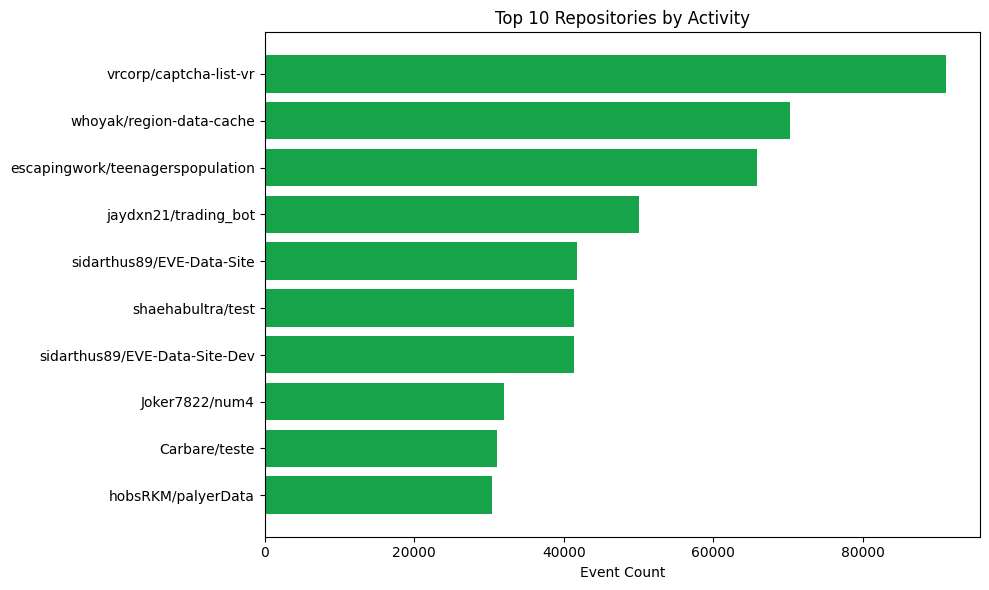

In [47]:
top10_repos = top_repos.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_repos["repository"], top10_repos["event_count"], color="#16a34a")
plt.gca().invert_yaxis()
plt.xlabel("Event Count")
plt.title("Top 10 Repositories by Activity")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "top10_repositories.png"), dpi=150)
plt.show()


#### Top 10 Organizations by Activity

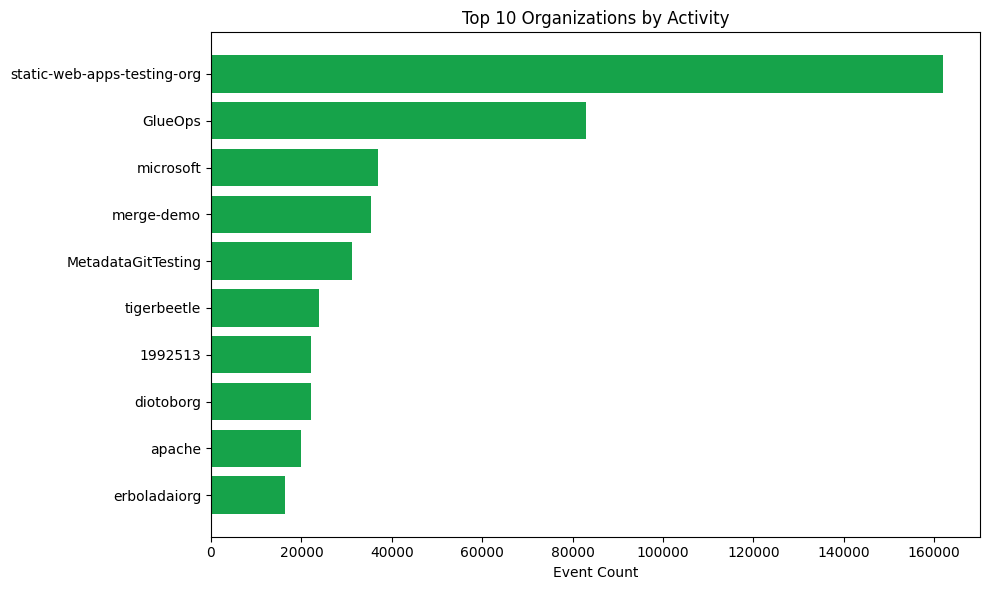

In [48]:
top10_orgs = top_orgs.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_orgs["organization"], top10_orgs["event_count"], color="#16a34a")
plt.gca().invert_yaxis()
plt.xlabel("Event Count")
plt.title("Top 10 Organizations by Activity")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "top10_organizations.png"), dpi=150)
plt.show()


###User Activity Distribution

A log-scale histogram of events-per-user makes the underlying long-tail
pattern visible: the large majority of users generate only a handful of
events, while a small number of highly active users or bots account for a
disproportionate share of total activity.

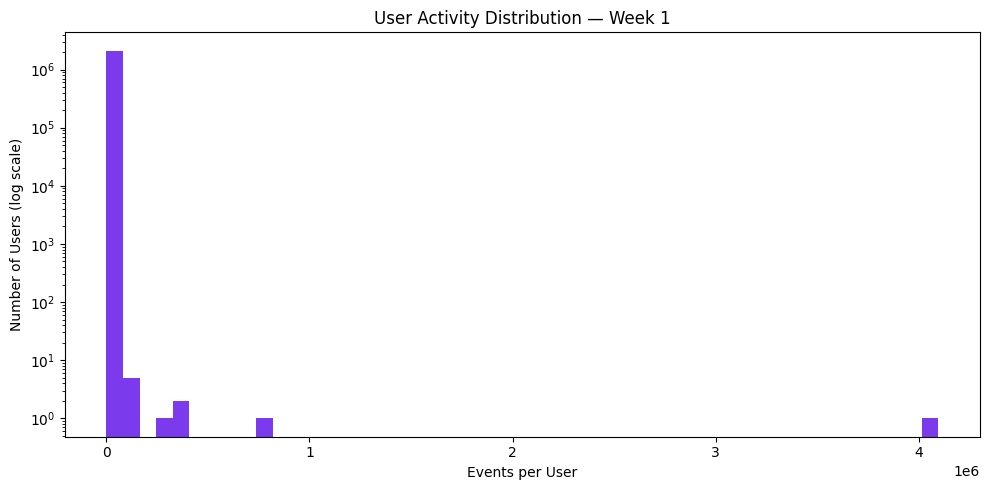

Median events per user : 2.0
Mean events per user   : 11.73
Max events (single user): 4,096,316


In [49]:
user_event_counts = list(actor_counter.values())

plt.figure(figsize=(10, 5))
plt.hist(user_event_counts, bins=50, color="#7c3aed")
plt.yscale("log")
plt.xlabel("Events per User")
plt.ylabel("Number of Users (log scale)")
plt.title("User Activity Distribution — Week 1")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_PATH, "user_activity_distribution.png"), dpi=150)
plt.show()

print(f"Median events per user : {pd.Series(user_event_counts).median()}")
print(f"Mean events per user   : {pd.Series(user_event_counts).mean():.2f}")
print(f"Max events (single user): {max(user_event_counts):,}")


### Schema Discovery — Sample Payloads

One representative payload is captured per event type during the single-pass
scan in Section 3. Because payload structure varies significantly by event
type, this catalog directly informs the field-extraction logic used when
designing the fact tables in the ETL phase.

In [50]:
from pprint import pprint

for event_type, payload in sample_payloads.items():
    print("\n" + "=" * 70)
    print(event_type)
    print("=" * 70)
    pprint(payload, depth=2)



IssueCommentEvent
{'action': 'created',
 'comment': {'body': '## ❓ Code Generation Drift Detection\n'
                     '\n'
                     '**Status:** \n'
                     '**Regeneration needed:** No\n'
                     '\n'
                     '\n'
                     '---\n'
                     '*Automated by [AE-Framework '
                     'Codegen](https://github.com/itdojp/ae-framework/actions/runs/20629343934)*',
             'created_at': '2026-01-01T00:00:00Z',
             'html_url': 'https://github.com/itdojp/ae-framework/pull/1330#issuecomment-3703070924',
             'id': 3703070924,
             'issue_url': 'https://api.github.com/repos/itdojp/ae-framework/issues/1330',
             'node_id': 'IC_kwDOPbMttM7cuGDM',
             'performed_via_github_app': {...},
             'reactions': {...},
             'updated_at': '2026-01-01T00:00:00Z',
             'url': 'https://api.github.com/repos/itdojp/ae-framework/issues/comments/3703070924

### Save Reports

All profiling outputs generated in this notebook are exported to a `reports/`
directory as CSV artifacts, ensuring the analysis is reproducible and
reviewable outside the notebook itself.

In [52]:
errors_df = pd.DataFrame(error_log)

profile_df.to_csv(os.path.join(REPORTS_PATH, "overall_summary.csv"), index=False)
event_df.to_csv(os.path.join(REPORTS_PATH, "event_distribution.csv"), index=False)
daily_df.to_csv(os.path.join(REPORTS_PATH, "daily_distribution.csv"), index=False)
hourly_df.to_csv(os.path.join(REPORTS_PATH, "hourly_distribution.csv"), index=False)
public_df.to_csv(os.path.join(REPORTS_PATH, "public_vs_private.csv"), index=False)
missing_df.to_csv(os.path.join(REPORTS_PATH, "missing_value_analysis.csv"), index=False)
top_users.to_csv(os.path.join(REPORTS_PATH, "top_users.csv"), index=False)
top_repos.to_csv(os.path.join(REPORTS_PATH, "top_repositories.csv"), index=False)
top_orgs.to_csv(os.path.join(REPORTS_PATH, "top_orgs.csv"), index=False)
data_dictionary.to_csv(os.path.join(REPORTS_PATH, "data_dictionary.csv"), index=False)

if not errors_df.empty:
    errors_df.to_csv(os.path.join(REPORTS_PATH, "error_log.csv"), index=False)

print("All reports saved to:", REPORTS_PATH)
print(sorted(os.listdir(REPORTS_PATH)))


All reports saved to: /content/drive/MyDrive/GitHub_Engineering_Intelligence/reports
['daily_activity.png', 'daily_distribution.csv', 'data_dictionary.csv', 'event_distribution.csv', 'event_type_distribution.png', 'hourly_activity.png', 'hourly_distribution.csv', 'missing_value_analysis.csv', 'overall_summary.csv', 'public_vs_private.csv', 'public_vs_private.png', 'top10_organizations.png', 'top10_repositories.png', 'top_orgs.csv', 'top_repositories.csv', 'top_users.csv', 'user_activity_distribution.png']


###Key Findings

*(Exact figures are available in the Dataset Statistics Dashboard, Section 4 —
this section interprets what those numbers mean.)*

- Successfully processed **7 consecutive days** of GH Archive data (168 files)
  in a single pass over the raw dataset.
- Validation confirmed the dataset is almost entirely clean, with a success
  rate well above 99.99% across all 7 days.
- **PushEvent** accounts for the majority of recorded activity, consistent
  with GitHub's overall public event mix, followed by issue- and
  pull-request-related events.
- The dataset spans **16 distinct GitHub event types**, each with a different
  payload structure — now fully cataloged in the Data Dictionary and sample
  payload sections for use in ETL design.
- No unresolved duplicate event IDs were found beyond those noted in
  Section 11, supporting the dataset's reliability as a unique-event source.
- Missing `org` fields are expected rather than a defect, reflecting the
  large share of GitHub activity from individually owned repositories.
- Activity is heavily concentrated: a small number of users, repositories,
  and organizations account for a disproportionate share of total events,
  consistent with GitHub's real-world long-tail contribution pattern.
- Hourly aggregation reveals a clear activity cycle by UTC hour, providing
  useful context for load patterns ahead of downstream analytics.
- The dataset is now validated, profiled, and documented — data dictionary,
  distributions, top contributors, and exported reports — and is ready to
  support the design of a dimensional warehouse and subsequent analytics.

#### Next Steps

Proceed to Notebook 02: design the PostgreSQL star schema (dimension and
fact tables) using the sample payloads and data dictionary established here,
then build the Python ETL pipeline to populate it from the validated 7-day
dataset.